In [26]:
import pathlib
from os import path, getcwd, chdir

import numpy as np
from tqdm import tqdm

chdir(r'C:\Users\IanFu\Desktop\~1_CURRENT\efsprapy\01-analysis\sensitivity_sprinkler_type')


def read_data(parent_dir: pathlib.Path) -> (list, list):
    folders = [item for item in parent_dir.iterdir() if item.is_dir()]
    folders.sort()
    list_act_temp = list()
    list_p_ig = list()
    for folder in tqdm(folders):
        case_name = folder.name
        act_temp = int(case_name)
        fp_output = folder / f'{folder.name}_out.csv'
        try:
            assert path.exists(fp_output), f'file does not exist {fp_output}'
        except AssertionError:
            continue
        mcs_output = np.genfromtxt(fp_output, delimiter=",", skip_header=1)

        N = np.shape(mcs_output)[0]

        # find all iterations that ignition occurred
        t_ig_ftp = mcs_output[:, 2]
        P_ig = sum(np.logical_and(t_ig_ftp > 0, t_ig_ftp < np.inf)) / N

        list_act_temp.append(act_temp)
        list_p_ig.append(P_ig)
    return np.array(list_act_temp), np.array(list_p_ig)


data = {
    'act_temp': read_data(pathlib.Path(getcwd(), 'act_temp')),
    'rti': read_data(pathlib.Path(getcwd(), 'rti')),
}

100%|██████████| 9/9 [00:00<00:00, 1500.05it/s]


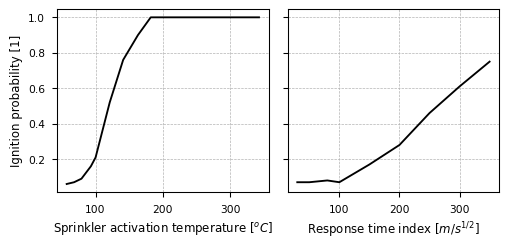

In [33]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

fig, (ax1, ax2) = plt.subplots(figsize=(2.7 * 2, 2.7), ncols=2, dpi=96, sharey=True)

ax1.plot(*data['act_temp'], c='k')
ax2.plot(*data['rti'], c='k')

ax1.grid(which="both", ls="--", lw=0.5)
ax2.grid(which="both", ls="--", lw=0.5)
ax1.set_xlabel('Sprinkler activation temperature [$^oC$]')
ax1.set_ylabel('Ignition probability [1]')
ax2.set_xlabel('Response time index [$m/s^{1/2}$]')

fig.tight_layout()

In [25]:
data

{'act_temp': (array([ 57,  68,  79,  93, 100, 121, 141, 163, 182, 204, 227, 260, 286,
         343]),
  array([0.06, 0.07, 0.09, 0.16, 0.21, 0.52, 0.76, 0.9 , 1.  , 1.  , 1.  ,
         1.  , 1.  , 1.  ]))}